In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

silver = Path("../datalake_silver/")

df_reddit = pd.read_parquet(list(silver.glob("reddit_*.parquet"))[-1])
df_lsv = pd.read_parquet(list(silver.glob("lasillavacia_*.parquet"))[-1])

print(f"Reddit: {df_reddit.shape}")
print(f"La Silla Vacía: {df_lsv.shape}")

Reddit: (243, 9)
La Silla Vacía: (75, 12)


In [2]:
print("=== Null rates Reddit ===")
null_rates = (df_reddit.isnull().sum() / len(df_reddit) * 100).round(2)
print(null_rates)

=== Null rates Reddit ===
title          0.0
title_clean    0.0
text           0.0
text_clean     0.0
author         0.0
date           0.0
score          0.0
url            0.0
source_file    0.0
dtype: float64


In [3]:
print("=== Null rates La Silla Vacía ===")
null_rates_lsv = (df_lsv.isnull().sum() / len(df_lsv) * 100).round(2)
print(null_rates_lsv)

=== Null rates La Silla Vacía ===
titulo             0.0
titulo_clean       0.0
autor              0.0
fecha              0.0
extracto           0.0
extracto_clean     0.0
contenido          0.0
contenido_clean    0.0
etiquetas          0.0
url                0.0
fuente             0.0
source_file        0.0
dtype: float64


In [4]:
print("=== Text length statistics La Silla Vacía ===")
df_lsv["titulo_length"] = df_lsv["titulo"].str.len()
df_lsv["contenido_length"] = df_lsv["contenido"].str.len()
print(df_lsv[["titulo_length", "contenido_length"]].describe())

=== Text length statistics La Silla Vacía ===
       titulo_length  contenido_length
count      75.000000         75.000000
mean       64.960000       9934.946667
std        17.599478       5465.086864
min        14.000000        304.000000
25%        58.500000       6232.000000
50%        71.000000      10653.000000
75%        75.000000      12893.500000
max        94.000000      24664.000000


In [5]:
print("=== Score outlier analysis Reddit ===")
Q1 = df_reddit["score"].quantile(0.25)
Q3 = df_reddit["score"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_reddit[(df_reddit["score"] < lower) | (df_reddit["score"] > upper)]
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df_reddit)*100:.2f}%)")

=== Score outlier analysis Reddit ===
Q1: 0.0, Q3: 7.0, IQR: 7.0
Lower bound: -10.5, Upper bound: 17.5
Outliers: 19 (7.82%)


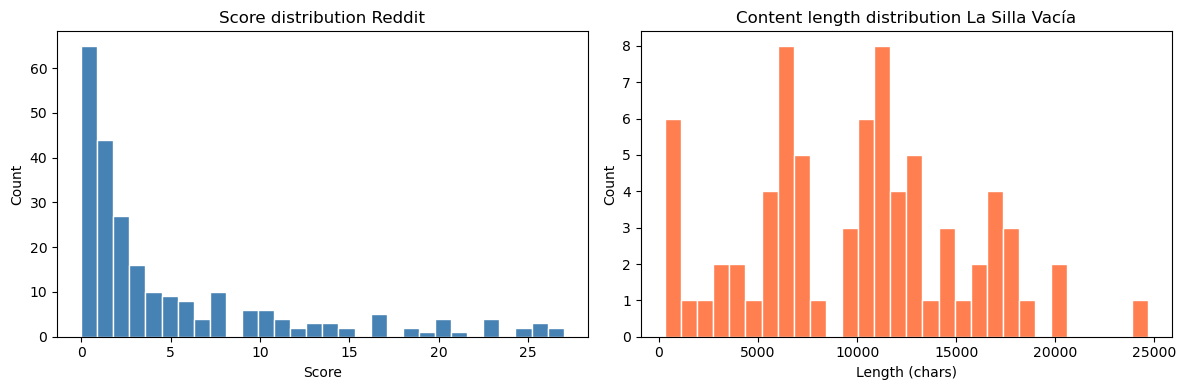

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_reddit["score"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Score distribution Reddit")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")

axes[1].hist(df_lsv["contenido_length"], bins=30, color="coral", edgecolor="white")
axes[1].set_title("Content length distribution La Silla Vacía")
axes[1].set_xlabel("Length (chars)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../notebooks/data_quality_plots.png", dpi=150)
plt.show()

In [7]:
print("=== Date range Reddit ===")
print(f"Min: {df_reddit['date'].min()}")
print(f"Max: {df_reddit['date'].max()}")

print("\n=== Date range La Silla Vacía ===")
print(f"Min: {df_lsv['fecha'].min()}")
print(f"Max: {df_lsv['fecha'].max()}")

=== Date range Reddit ===
Min: 2026-04-05 04:11:31
Max: 2026-05-27 00:15:21

=== Date range La Silla Vacía ===
Min: 2026-04-02 05:05:00
Max: 2026-05-26 18:35:27


In [8]:
print("=== Duplicate analysis ===")
dup_reddit = df_reddit.duplicated(subset=["url"]).sum()
dup_lsv = df_lsv.duplicated(subset=["url"]).sum()
print(f"Reddit duplicates: {dup_reddit} ({dup_reddit/len(df_reddit)*100:.2f}%)")
print(f"La Silla Vacía duplicates: {dup_lsv} ({dup_lsv/len(df_lsv)*100:.2f}%)")

=== Duplicate analysis ===
Reddit duplicates: 0 (0.00%)
La Silla Vacía duplicates: 0 (0.00%)
